<a href="https://colab.research.google.com/github/ollihansen90/Mathe-SH/blob/main/Schiffeversenken_Termin5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Schiffe Versenken - Termin 4
## Fragen?
Solltet ihr Fragen zum Code oder Probleme mit Colab haben, schickt uns gerne eine Mail:

*   h.hansen@uni-luebeck.de
*   mika.kohlhammer@student.uni-luebeck.de
*   gun.ingwersen@student.uni-luebeck.de

## 🤖 Unsere KI übernimmt das Ruder! 🚢💡

In den letzten Terminen haben wir unser Spiel **Schiffe versenken** Schritt für Schritt aufgebaut.  
Unser Spielfeld funktioniert, Schiffe können platziert werden, und wir können Treffer und Fehlversuche erkennen. 🎯💥

In [2]:
# utils.py (möglicherweise als eigene Datei zum Importieren, siehe bspw. https://github.com/ollihansen90/Mathe-SH/blob/main/SudokuSolver.ipynb)
import random
def reset_spielfeld():
    # Erstellt ein leeres Spielfeld
    return [[0 for i in range(10)] for j in range(10)]

def male_feld(feld):
    # Zeichnet das Spielfeld auf der Konsole
    print("  │ 1 2 3 4 5 6 7 8 9 0 │\n──┼─────────────────────┼─");alphabet = "abcdefghijklmnopqrstuvwxyz"
    for i, zeile in enumerate(feld):
        string = alphabet[i] + " │ "
        for zeichen in zeile: string = string+["\x1b[34m~\x1b[30m", "s", "\x1b[31mx\x1b[30m", "t", "z"][zeichen] + " "
        string = string + "│";print(string)
    print("──┼─────────────────────┼─")

def setze_schiff(feld, pos, dir, l):
    # Setzt Schiff in das Spielfeld
    #   pos: Koordinaten, [int, int]
    #   dir: Ausrichtung, 0 horizontal (waagerecht), 1 vertikal (senkrecht), int
    #   l: Länge, int
    for i in range(l):
        if dir==0: feld[pos[0]][pos[1]+i] = 1
        else: feld[pos[0]+i][pos[1]] = 1
    return feld

def padding(feld):
    # Rahmen mit Nullen
    #   feld: Spielfeld, Liste von Listen
    output = [[0 for i in range(12)] for j in range(12)]
    for i in range(10):
        for j in range(10): output[i+1][j+1] = feld[i][j]
    return output

def erlaubt(feld, dir, l):
    # Erstellt für gegebenes Feld die möglichen Startposition eines Schiffes
    #   feld: Spielfeld, Liste von Listen mit int
    #   dir: Ausrichtung, 0 horizontal (waagerecht), 1 vertikal (senkrecht), int
    #   l: Länge, int
    hilfsfeld = [[1 for i in range(10)] for j in range(10)]; p_feld = padding(feld)
    # Rand
    if dir==0:
        for zeile in range(10):
            for spalte in range(10-l+1, 10): hilfsfeld[zeile][spalte] = 0
    else:
        for zeile in range(10-l+1, 10):
            for spalte in range(10): hilfsfeld[zeile][spalte] = 0
    # Schiff-Nachbarn
    for zeile in range(10):
        for spalte in range(10): # Tile zeile, spalte
            if hilfsfeld[zeile][spalte] == 0:
                continue
            summe = 0
            for kx in range(3): # k für Kernel
                for ky in range(3): summe = summe + p_feld[zeile+kx][spalte+ky]

            if summe>0: hilfsfeld[zeile][spalte] = 2

    # Crash
    for zeile in range(10):
        for spalte in range(10): # Tile zeile, spalte
            if hilfsfeld[zeile][spalte]==2:
                for i in range(1, l):
                    if dir==1 and zeile-i>=0: hilfsfeld[zeile-i][spalte] = 3
                    elif dir==0 and spalte-i>=0: hilfsfeld[zeile][spalte-i] = 3

    output = []
    for x in range(len(hilfsfeld)):
        for y in range(len(hilfsfeld[x])):
            if hilfsfeld[x][y] == 1: output.append([x, y])
    return output

def generiere_spielfeld(schiffe=[5,4,3,3,2]):
    # Erstellt ein leeres Spielfeld und setzt Schiffe rein
    #   schiffe: Liste von Schifflängen
    spielfeld = reset_spielfeld()
    for l in schiffe:dir = random.randint(0,1);erlaubtliste = erlaubt(spielfeld, dir, l);pos = erlaubtliste[random.randint(0,len(erlaubtliste)-1)];spielfeld = setze_schiff(spielfeld, pos, dir, l)
    return spielfeld

def eingabe():
    # Lässt den Spieler eine Position auswählen
    eingabe = ""
    while not gueltig(eingabe): eingabe = input("Wähle ein Feld: ").lower()
    output = False
    for i in range(10):
        if eingabe[0]=="abcdefghij"[i]: output = [i,(int(eingabe[1])-1)%10]
    return output

def spiel_ende(spielfeld, loesung):
    # Bestimmt, ob ein Spiel beendet ist. Spiel ist beendet, wenn alle Schiffe gefunden wurden
    #   spielfeld, loesung: Liste von Listen mit int
    for zeile in range(len(loesung)):
        if 1 not in loesung[zeile]: continue
        for spalte in range(len(loesung[0])):
            if loesung[zeile][spalte]==1 and spielfeld[zeile][spalte]==0: return False
    return True

def gueltig(eingabe):
    # Überprüft, ob eine Eingabe legal ist.
    #   eingabe: String
    return len(eingabe)==2 and eingabe[0] in "abcdefghij" and eingabe[1] in "1234567890"

def starte_spiel():
    spielfeld = reset_spielfeld();loesung = generiere_spielfeld();male_feld(spielfeld)
    #male_feld(loesung)
    counter = 0
    while not spiel_ende(spielfeld, loesung):
        koordinaten = eingabe()
        counter+=1
        if loesung[koordinaten[0]][koordinaten[1]]==1:
            spielfeld[koordinaten[0]][koordinaten[1]] = 1
        else:
            spielfeld[koordinaten[0]][koordinaten[1]] = 2
        male_feld(spielfeld)
    return counter

def spiel():
    print("Du hast", starte_spiel(), "Versuche gebraucht.")

spiel()

  │ 1 2 3 4 5 6 7 8 9 0 │
──┼─────────────────────┼─
a │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
b │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
c │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
d │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
e │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
f │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
g │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
h │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
i │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
j │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
──┼─────────────────────┼─


KeyboardInterrupt: Interrupted by user

Heute machen wir den nächsten großen Schritt:

## 🧠 Wir bauen eine KI für unser Spiel!

Ab jetzt spielt nicht nur ein Mensch gegen einen Menschen -  
sondern **eine künstliche Intelligenz** übernimmt eine Seite! 🤖⚓

Keine Sorge:  
Unsere KI ist am Anfang noch ganz einfach.  
Sie wird ihre Züge **zufällig auswählen** 🎲

Das bedeutet:
- Die KI sucht sich ein freies Feld aus 🟦  
- Sie schießt darauf 💥  
- Und wir prüfen, ob es ein Treffer oder ein Fehlversuch war  

Später könnten wir die KI sogar schlauer machen 🧠✨  
Aber heute starten wir mit der einfachsten Version:  
**Eine Zufalls-KI!**

---

## 🎯 Unser Ziel heute:

- Eine Funktion schreiben, die zufällige Koordinaten erzeugt 🎲  
- Sicherstellen, dass kein Feld doppelt gewählt wird 🚫  
- Die KI automatisch schießen lassen 🤖💥  
- Unser Spiel damit erweitern 🛠️  

Am Ende des Tages spielt unser eigenes Programm selbstständig mit! 🎉🚀

Los geht’s – wir bringen unserer KI das Schießen bei! 😄

In [35]:
def ki_zufall(spielfeld):
    # Erhält Spielfeld, gibt Koordinaten zurück, z.B. "a4", "c1", "h0"
    zeilenzahl = random.randint(0,9)
    while 0 not in spielfeld[zeilenzahl]:
        zeilenzahl = random.randint(0,9)

    spaltenzahl = random.randint(0,9)
    while spielfeld[zeilenzahl][spaltenzahl] != 0:
        spaltenzahl = random.randint(0,9)


    return [zeilenzahl, spaltenzahl]

def starte_spiel_ki(ki):
    spielfeld = reset_spielfeld();loesung = generiere_spielfeld();#male_feld(spielfeld)
    #male_feld(loesung)
    counter = 0
    while not spiel_ende(spielfeld, loesung):
        koordinaten = ki(spielfeld)
        #print(koordinaten)
        counter+=1
        if loesung[koordinaten[0]][koordinaten[1]]==1:
            spielfeld[koordinaten[0]][koordinaten[1]] = 1
        else:
            spielfeld[koordinaten[0]][koordinaten[1]] = 2
        #male_feld(spielfeld)
    return counter


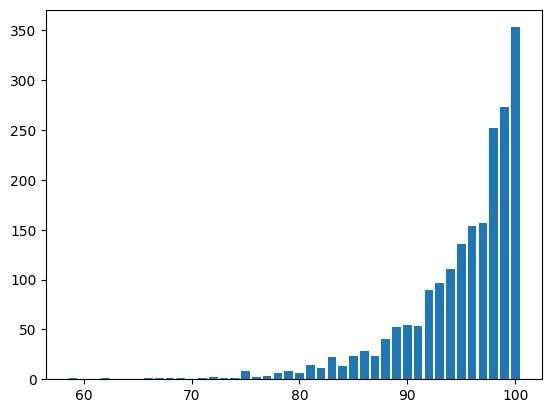

In [42]:
anzahldict = {}
for i in range(2000):
    anzahl = starte_spiel_ki(ki_zufall)
    if anzahl in anzahldict.keys():
        anzahldict[anzahl] += 1
    else:
        anzahldict[anzahl] = 1

import matplotlib.pyplot as plt
plt.figure()
plt.bar(anzahldict.keys(), anzahldict.values())
plt.show()